# Multi-Label Classification of Dental Findings in Panoramic Radiographs

This project develops a multi-label deep learning model for detecting dental findings in panoramic radiographs (OPGs).

A pretrained ResNet18 model is fine-tuned to predict 14 dental findings simultaneously.

The project includes:
- Data preparation from YOLO annotations
- Exploratory data analysis
- Multi-label classification with ResNet18
- Class imbalance handling
- Per-class threshold optimization
- Internal and external validation
- Error analysis
- Inference on individual OPG images

## 1. Imports and Configuration

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import (
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [2]:
NUM_CLASSES = 14
IMAGE_SIZE = 224
BATCH_SIZE = 16

class_names = {
    0: "Implant",
    1: "Prosthetic restoration",
    2: "Obturation",
    3: "Endodontic treatment",
    4: "Carious lesion",
    5: "Bone resorption",
    6: "Impacted tooth",
    7: "Apical periodontitis",
    8: "Root fragment",
    9: "Furcation lesion",
    10: "Apical surgery",
    11: "Root resorption",
    12: "Orthodontic device",
    13: "Surgical device"
}

label_columns = [
    class_names[i]
    for i in range(NUM_CLASSES)
]

## 2. Dataset Overview

This project uses a public panoramic dental radiography dataset hosted on **Zenodo**:

**Dataset for Automating Dental Condition Detection on Panoramic Radiographs**

**DOI:** `10.5281/zenodo.15487430`

The dataset contains panoramic dental radiographs (OPGs) together with YOLO-format bounding-box annotations for multiple dental findings.

### 2.1 Dataset Splits

The main dataset contains **1,628 OPGs**, divided into three predefined subsets:

- **Training set:** 1,375 OPGs
- **Validation set:** 153 OPGs
- **Internal test set:** 100 OPGs

An additional external validation set containing **180 OPGs** is also provided separately.

In this project, the predefined training, validation, and test splits are preserved.  
The additional external validation set is used to assess how well the final model generalizes beyond the main dataset splits.

### 2.2 Annotation Format

The original annotations are provided in **YOLO format**, where each line represents one annotated dental finding:

`class_id x_center y_center width height`

where:

- `class_id` identifies the dental finding
- `x_center` and `y_center` represent the normalized center coordinates of the bounding box
- `width` and `height` represent the normalized bounding-box dimensions

A single OPG may contain several annotations and may therefore contain multiple dental findings simultaneously.

### 2.3 Reformulating the Task as Multi-Label Classification

Although the original dataset contains bounding-box annotations suitable for object detection, this project reformulates the problem as **image-level multi-label classification**.

Instead of predicting the location of each finding, the model predicts whether each of the 14 dental findings is present anywhere in the complete panoramic radiograph.

For each OPG:

1. The corresponding YOLO annotation file is read.
2. The `class_id` from each annotation is extracted.
3. Duplicate class IDs are removed.
4. The remaining class IDs are converted into a **14-dimensional multi-hot target vector**.

For example, if an OPG contains findings with class IDs:

`0, 2, 4`

the corresponding target vector becomes:

`[1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]`

In this representation:

- `1` indicates that the finding is present in the OPG
- `0` indicates that the finding is not annotated in the OPG

Because several positions in the target vector can be equal to `1`, this is a **multi-label classification problem**, rather than a standard single-label classification problem.

The bounding-box coordinates are not used during classifier training. However, the original bounding-box annotations are retained for later visualization and error analysis.

### 2.4 Dental Findings

The model predicts the following 14 dental findings:

| Class ID | Dental Finding |
|---:|---|
| 0 | Implant |
| 1 | Prosthetic restoration |
| 2 | Obturation |
| 3 | Endodontic treatment |
| 4 | Carious lesion |
| 5 | Bone resorption |
| 6 | Impacted tooth |
| 7 | Apical periodontitis |
| 8 | Root fragment |
| 9 | Furcation lesion |
| 10 | Apical surgery |
| 11 | Root resorption |
| 12 | Orthodontic device |
| 13 | Surgical device |

### 2.5 Data Availability

The dataset itself is **not redistributed in this repository**.

Users who wish to reproduce the project should obtain the dataset directly from the original Zenodo source and follow the dataset's usage terms.

Only the code required for data preparation, model training, evaluation, and inference is included in this repository.

## 3. Data Preparation

The YOLO annotation files are converted into image-level multi-label targets.

For each OPG, all unique class IDs are extracted from its annotation file and converted into a 14-dimensional multi-hot vector.

Before constructing the final data tables, the image and annotation files are checked to ensure that every image has a corresponding label file.

### 3.1 Dataset Paths

In [3]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

In [4]:
MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [5]:
print("Project root:", PROJECT_ROOT)
print("Data:", DATA_DIR)
print("Models:", MODELS_DIR)
print("Results:", RESULTS_DIR)

Project root: C:\Users\User\Documents\opg-multilabel-classification
Data: C:\Users\User\Documents\opg-multilabel-classification\data
Models: C:\Users\User\Documents\opg-multilabel-classification\models
Results: C:\Users\User\Documents\opg-multilabel-classification\results


In [6]:
from pathlib import Path

print("Current working directory:")
print(Path.cwd())

print("\nParent directory:")
print(Path("..").resolve())

Current working directory:
C:\Users\User\Documents\opg-multilabel-classification\notebooks

Parent directory:
C:\Users\User\Documents\opg-multilabel-classification


In [7]:
train_dir = DATA_DIR / "train"
valid_dir = DATA_DIR / "valid"
test_dir = DATA_DIR / "test"

train_images_dir = train_dir / "images"
train_labels_dir = train_dir / "labels"

valid_images_dir = valid_dir / "images"
valid_labels_dir = valid_dir / "labels"

test_images_dir = test_dir / "images"
test_labels_dir = test_dir / "labels"

### 3.2 Data Integrity Check

Before processing the annotations, the image and label filenames are compared using their file stems.

This ensures that every OPG has a corresponding annotation file and that no unmatched files are present.

In [8]:
def check_split_integrity(images_dir, labels_dir):

    image_files = [
        file
        for file in images_dir.glob("*")
        if file.is_file()
    ]

    label_files = list(
        labels_dir.glob("*.txt")
    )

    image_stems = {
        file.stem
        for file in image_files
    }

    label_stems = {
        file.stem
        for file in label_files
    }

    print(f"Images: {len(image_files)}")
    print(f"Labels: {len(label_files)}")

    print(
        "Matching stems:",
        image_stems == label_stems
    )

    print(
        "Images without labels:",
        image_stems - label_stems
    )

    print(
        "Labels without images:",
        label_stems - image_stems
    )

In [9]:
print("TRAIN")
check_split_integrity(
    train_images_dir,
    train_labels_dir
)

print("\nVALIDATION")
check_split_integrity(
    valid_images_dir,
    valid_labels_dir
)

print("\nTEST")
check_split_integrity(
    test_images_dir,
    test_labels_dir
)

TRAIN
Images: 1375
Labels: 1375
Matching stems: True
Images without labels: set()
Labels without images: set()

VALIDATION
Images: 153
Labels: 153
Matching stems: True
Images without labels: set()
Labels without images: set()

TEST
Images: 100
Labels: 100
Matching stems: True
Images without labels: set()
Labels without images: set()


### 3.3 Converting YOLO Annotations to Multi-Hot Targets

Only the class ID from each YOLO annotation is required for image-level classification.

For each OPG:

1. All class IDs are extracted.
2. Duplicate class IDs are removed.
3. A 14-dimensional multi-hot target vector is created.

In [10]:
def build_records(
    labels_dir,
    images_dir,
    num_classes=NUM_CLASSES
):

    records = []

    label_files = sorted(
        labels_dir.glob("*.txt")
    )

    for label_file in label_files:

        image_matches = [
            file
            for file in images_dir.glob(
                f"{label_file.stem}.*"
            )
            if file.is_file()
        ]

        if len(image_matches) == 0:
            raise FileNotFoundError(
                f"No image found for {label_file.stem}"
            )

        image_name = image_matches[0].name

        class_ids = set()

        with open(label_file, "r") as f:

            for line in f:

                parts = line.split()

                if not parts:
                    continue

                class_id = int(parts[0])

                if not 0 <= class_id < num_classes:
                    raise ValueError(
                        f"Invalid class ID {class_id} "
                        f"in {label_file.name}"
                    )

                class_ids.add(class_id)

        target = [0] * num_classes

        for class_id in class_ids:
            target[class_id] = 1

        records.append({
            "image": image_name,
            "target": target
        })

    return records

### 3.4 Creating Multi-Label DataFrames

The generated records are converted into pandas DataFrames.

Each row represents one OPG, while the 14 dental findings are stored as separate binary columns.

In [11]:
def records_to_dataframe(
    records,
    label_columns
):

    df = pd.DataFrame(records)

    target_df = pd.DataFrame(
        df["target"].tolist(),
        columns=label_columns
    )

    final_df = pd.concat(
        [
            df["image"],
            target_df
        ],
        axis=1
    )

    return final_df

In [12]:
train_records = build_records(
    train_labels_dir,
    train_images_dir
)

valid_records = build_records(
    valid_labels_dir,
    valid_images_dir
)

test_records = build_records(
    test_labels_dir,
    test_images_dir
)

In [13]:
train_df = records_to_dataframe(
    train_records,
    label_columns
)

valid_df = records_to_dataframe(
    valid_records,
    label_columns
)

test_df = records_to_dataframe(
    test_records,
    label_columns
)

### 3.5 Final Split Verification

The final DataFrames are checked to verify their dimensions and ensure that all splits use the same label columns.

In [14]:
print("Train shape:", train_df.shape)
print("Validation shape:", valid_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1375, 15)
Validation shape: (153, 15)
Test shape: (100, 15)


In [15]:
assert list(train_df.columns) == list(valid_df.columns)
assert list(train_df.columns) == list(test_df.columns)

print("All splits have matching columns.")

All splits have matching columns.


In [16]:
train_df.head()

,image,Implant,Prosthetic restoration,Obturation,Endodontic treatment,Carious lesion,Bone resorption,Impacted tooth,Apical periodontitis,Root fragment,Furcation lesion,Apical surgery,Root resorption,Orthodontic device,Surgical device
0,1001.jpg,0,1,1,1,1,1,0,1,1,0,0,0,0,0
1,1002.jpg,1,1,1,1,1,0,0,0,0,0,0,0,0,1
2,1003.jpg,1,1,0,1,0,0,0,0,0,0,0,0,0,0
3,1004.jpg,0,0,0,0,1,1,0,1,1,0,0,0,0,0
4,1005.jpg,1,1,1,0,1,0,0,0,0,0,0,0,0,0


## 4. Exploratory Data Analysis

Before training the model, the distribution of dental findings is examined to better understand the multi-label nature of the dataset and the degree of class imbalance.

The analysis focuses on:

- Frequency of each dental finding
- Prevalence of each class
- Number of findings per OPG
- Distribution differences across the predefined dataset splits

### 4.1 Class Distribution in the Training Set

In [17]:
train_class_counts = train_df[label_columns].sum()

train_class_prevalence = (
    train_class_counts / len(train_df)
) * 100

class_distribution_df = pd.DataFrame({
    "Count": train_class_counts,
    "Prevalence (%)": train_class_prevalence
})

class_distribution_df = class_distribution_df.sort_values(
    "Count",
    ascending=False
)

class_distribution_df.round(2)

,Count,Prevalence (%)
Carious lesion,816,59.35
Endodontic treatment,782,56.87
Obturation,745,54.18
Prosthetic restoration,540,39.27
Apical periodontitis,521,37.89
Bone resorption,438,31.85
Root fragment,416,30.25
Impacted tooth,327,23.78
Surgical device,213,15.49
Orthodontic device,196,14.25


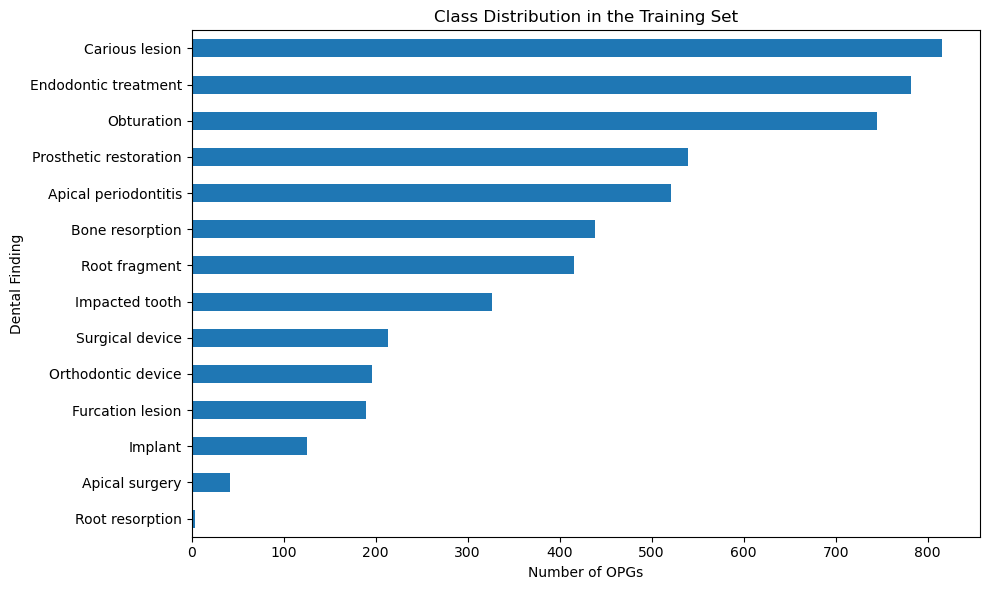

In [18]:
plt.figure(figsize=(10, 6))

class_distribution_df["Count"].sort_values().plot(
    kind="barh"
)

plt.xlabel("Number of OPGs")
plt.ylabel("Dental Finding")
plt.title("Class Distribution in the Training Set")

plt.tight_layout()
plt.show()

The training set shows substantial class imbalance. Several findings are common, while others occur in only a small number of OPGs.

This imbalance is important because rare classes may be more difficult for the model to learn and evaluate reliably.

### 4.2 Number of Findings per OPG

In [19]:
train_findings_per_image = train_df[
    label_columns
].sum(axis=1)

print(
    "Minimum findings per OPG:",
    train_findings_per_image.min()
)

print(
    "Maximum findings per OPG:",
    train_findings_per_image.max()
)

print(
    "Mean findings per OPG:",
    train_findings_per_image.mean()
)

print(
    "Median findings per OPG:",
    train_findings_per_image.median()
)

Minimum findings per OPG: 1
Maximum findings per OPG: 9
Mean findings per OPG: 3.895272727272727
Median findings per OPG: 4.0


In [20]:
findings_distribution = (
    train_findings_per_image
    .value_counts()
    .sort_index()
)

findings_distribution

1     75
2    192
3    304
4    332
5    269
6    136
7     47
8     13
9      7
Name: count, dtype: int64

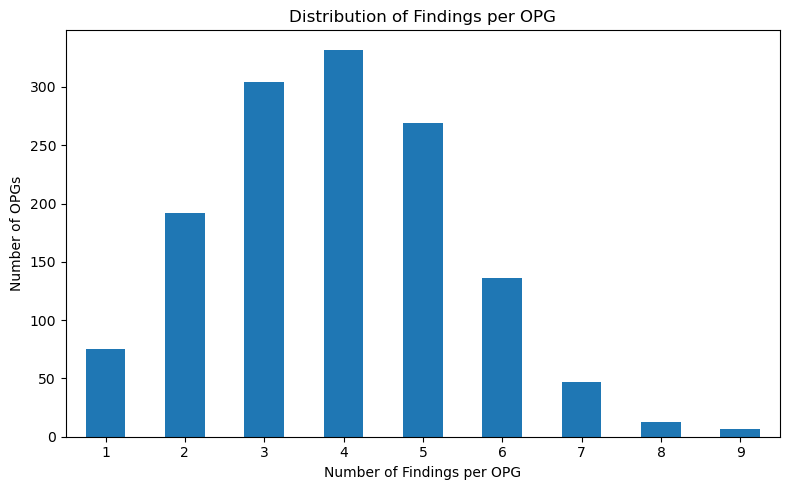

In [21]:
plt.figure(figsize=(8, 5))

findings_distribution.plot(
    kind="bar"
)

plt.xlabel("Number of Findings per OPG")
plt.ylabel("Number of OPGs")
plt.title("Distribution of Findings per OPG")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Most OPGs contain multiple dental findings rather than a single condition.

This confirms that the task is naturally multi-label: several findings may need to be predicted simultaneously from the same panoramic radiograph.

### 4.3 Class Prevalence Across Dataset Splits

In [22]:
split_prevalence = pd.DataFrame({
    "Train (%)":
        train_df[label_columns].mean() * 100,

    "Validation (%)":
        valid_df[label_columns].mean() * 100,

    "Test (%)":
        test_df[label_columns].mean() * 100
})

split_prevalence.round(2)

,Train (%),Validation (%),Test (%)
Implant,9.16,6.54,11.0
Prosthetic restoration,39.27,32.03,40.0
Obturation,54.18,52.29,72.0
Endodontic treatment,56.87,51.63,67.0
Carious lesion,59.35,70.59,43.0
Bone resorption,31.85,32.03,22.0
Impacted tooth,23.78,30.07,24.0
Apical periodontitis,37.89,29.41,40.0
Root fragment,30.25,28.10,13.0
Furcation lesion,13.82,9.80,9.0


In [23]:
zero_support_classes = []

for class_name in label_columns:

    valid_support = valid_df[class_name].sum()
    test_support = test_df[class_name].sum()

    if valid_support == 0 or test_support == 0:

        zero_support_classes.append({
            "Class": class_name,
            "Validation support": valid_support,
            "Test support": test_support
        })

pd.DataFrame(zero_support_classes)

,Class,Validation support,Test support
0,Root resorption,0,0


`Root resorption` has zero positive samples in both the validation and internal test sets.

Therefore, per-class evaluation metrics for this finding cannot be interpreted reliably on these splits.

## 5. Image Preprocessing

The OPG images are preprocessed before being passed to the neural network.

A pretrained ResNet18 model is used in this project. Therefore, the images are normalized using the ImageNet mean and standard deviation values used for the pretrained model.

Each image is:

1. Resized to `224 × 224` pixels
2. Converted to a PyTorch tensor
3. Normalized using ImageNet statistics

No data augmentation is applied in the current version of the project.

In [24]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

In [25]:
transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

### 5.1 Preprocessing Verification

A sample training image is loaded and transformed to verify the final tensor dimensions.

In [26]:
sample_image_path = (
    train_images_dir /
    train_df.iloc[0]["image"]
)

sample_image = Image.open(
    sample_image_path
).convert("RGB")

sample_tensor = transform(
    sample_image
)

print(
    "Original image size:",
    sample_image.size
)

print(
    "Transformed tensor shape:",
    sample_tensor.shape
)

Original image size: (2652, 1536)
Transformed tensor shape: torch.Size([3, 224, 224])


## 6. PyTorch Dataset and DataLoaders

A custom PyTorch `Dataset` is used to connect the processed DataFrames with the corresponding OPG image files.

For each sample, the dataset:

1. Loads the OPG image
2. Converts it to RGB
3. Applies the preprocessing transform
4. Extracts the 14-dimensional multi-label target
5. Returns the image tensor and target tensor

DataLoaders are then created to provide the samples to the model in mini-batches.

### 6.1 Custom Dataset

In [27]:
class OPGDataset(Dataset):

    def __init__(
        self,
        dataframe,
        images_dir,
        label_columns,
        transform=None
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.images_dir = images_dir
        self.label_columns = label_columns
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_path = (
            self.images_dir / row["image"]
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        target = row[
            self.label_columns
        ].to_numpy(dtype=np.float32)

        target = torch.tensor(
            target,
            dtype=torch.float32
        )

        return image, target

### 6.2 Creating Dataset Objects

In [28]:
train_dataset = OPGDataset(
    dataframe=train_df,
    images_dir=train_images_dir,
    label_columns=label_columns,
    transform=transform
)

valid_dataset = OPGDataset(
    dataframe=valid_df,
    images_dir=valid_images_dir,
    label_columns=label_columns,
    transform=transform
)

test_dataset = OPGDataset(
    dataframe=test_df,
    images_dir=test_images_dir,
    label_columns=label_columns,
    transform=transform
)

In [29]:
print("Training samples:", len(train_dataset))
print("Validation samples:", len(valid_dataset))
print("Test samples:", len(test_dataset))

Training samples: 1375
Validation samples: 153
Test samples: 100


### 6.3 Creating DataLoaders

The training DataLoader uses shuffling so that the order of training samples changes between epochs.

Validation and test samples are not shuffled because their order does not affect model evaluation.

In [30]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

### 6.4 Batch Verification

In [31]:
images, targets = next(
    iter(train_loader)
)

print("Image batch shape:", images.shape)
print("Target batch shape:", targets.shape)

print("Image dtype:", images.dtype)
print("Target dtype:", targets.dtype)

Image batch shape: torch.Size([16, 3, 224, 224])
Target batch shape: torch.Size([16, 14])
Image dtype: torch.float32
Target dtype: torch.float32


In [32]:
assert images.shape[1:] == (
    3,
    IMAGE_SIZE,
    IMAGE_SIZE
)

assert targets.shape[1] == NUM_CLASSES

print("Dataset and DataLoader verification passed.")

Dataset and DataLoader verification passed.


## 7. Model Architecture

A pretrained **ResNet18** is used as the backbone of the multi-label classifier.

The model is initialized with ImageNet pretrained weights to take advantage of features learned from a large-scale image dataset.

The original ResNet18 classification head produces 1,000 outputs for ImageNet classes. Since this project predicts 14 dental findings, the final fully connected layer is replaced with a new linear layer containing 14 outputs.

Each output corresponds to one dental finding and represents a raw model score (logit). These logits are later converted to probabilities using the sigmoid function.

### 7.1 Loading the Pretrained ResNet18

In [33]:
model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

In [34]:
print(model.fc)

Linear(in_features=512, out_features=1000, bias=True)


### 7.2 Replacing the Classification Head

The original ImageNet classification layer is replaced with a new fully connected layer containing one output for each dental finding.

In [35]:
num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    NUM_CLASSES
)

print(model.fc)

Linear(in_features=512, out_features=14, bias=True)


### 7.3 Computing Device

In [36]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: cpu


In [37]:
model = model.to(device)

### 7.4 Model Output Verification

A sample batch is passed through the model to verify that the output dimensions match the 14 target classes.

In [38]:
sample_images, sample_targets = next(
    iter(train_loader)
)

sample_images = sample_images.to(device)

with torch.no_grad():
    sample_outputs = model(
        sample_images
    )

print(
    "Input shape:",
    sample_images.shape
)

print(
    "Output shape:",
    sample_outputs.shape
)

Input shape: torch.Size([16, 3, 224, 224])
Output shape: torch.Size([16, 14])


In [39]:
assert sample_outputs.shape == (
    sample_images.shape[0],
    NUM_CLASSES
)

print(
    "Model output verification passed."
)

Model output verification passed.


### Multi-Label Output

The 14 outputs are treated independently.

Unlike multi-class classification, where a softmax operation forces the model to select one class, this project uses independent sigmoid probabilities because multiple dental findings may be present in the same OPG.

Therefore, the model is trained using binary cross-entropy for each output class.

## 8. Model Training

Training is performed in three stages:

1. **Baseline transfer learning:** only the final classification layer is trained while the pretrained ResNet18 backbone remains frozen.
2. **Fine-tuning:** the final ResNet block (`layer4`) and classification head are jointly optimized.
3. **Class-weighted fine-tuning:** class imbalance is addressed using a weighted binary cross-entropy loss.

The validation set is used for model selection and threshold optimization.  
The internal test set is kept separate from the training process.

### 8.1 Training Setup

In [40]:
criterion = nn.BCEWithLogitsLoss()

`BCEWithLogitsLoss` is appropriate for multi-label classification because each of the 14 findings is treated as an independent binary prediction.

The loss operates directly on model logits, so a sigmoid activation is **not** applied before computing the training loss.

### Training and Validation Functions

Reusable functions are defined to train the model for one epoch and evaluate the validation loss.

In [41]:
def train_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0

    for images, targets in dataloader:

        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            targets
        )

        loss.backward()
        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

    epoch_loss = (
        running_loss / len(dataloader.dataset)
    )

    return epoch_loss

In [42]:
def evaluate_loss(
    model,
    dataloader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    with torch.no_grad():

        for images, targets in dataloader:

            images = images.to(device)
            targets = targets.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                targets
            )

            running_loss += (
                loss.item() * images.size(0)
            )

    epoch_loss = (
        running_loss / len(dataloader.dataset)
    )

    return epoch_loss

### 8.2 Baseline Transfer Learning

As an initial baseline, all pretrained ResNet18 layers are frozen and only the newly initialized classification head is trained.

This preserves the ImageNet feature extractor while adapting the final layer to the 14 dental findings.

In [43]:
for param in model.parameters():
    param.requires_grad = False

In [44]:
for param in model.fc.parameters():
    param.requires_grad = True

In [45]:
trainable_parameters = [
    name
    for name, param in model.named_parameters()
    if param.requires_grad
]

trainable_parameters

['fc.weight', 'fc.bias']

In [46]:
baseline_optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=1e-3
)

In [47]:
BASELINE_EPOCHS = 6

baseline_history = {
    "train_loss": [],
    "val_loss": []
}

for epoch in range(BASELINE_EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        baseline_optimizer,
        device
    )

    val_loss = evaluate_loss(
        model,
        valid_loader,
        criterion,
        device
    )

    baseline_history["train_loss"].append(
        train_loss
    )

    baseline_history["val_loss"].append(
        val_loss
    )

    print(
        f"Epoch {epoch + 1}/{BASELINE_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch 1/6 | Train Loss: 0.4912 | Val Loss: 0.4374
Epoch 2/6 | Train Loss: 0.4413 | Val Loss: 0.4036
Epoch 3/6 | Train Loss: 0.4189 | Val Loss: 0.4009
Epoch 4/6 | Train Loss: 0.4057 | Val Loss: 0.3985
Epoch 5/6 | Train Loss: 0.3980 | Val Loss: 0.3905
Epoch 6/6 | Train Loss: 0.3893 | Val Loss: 0.3905


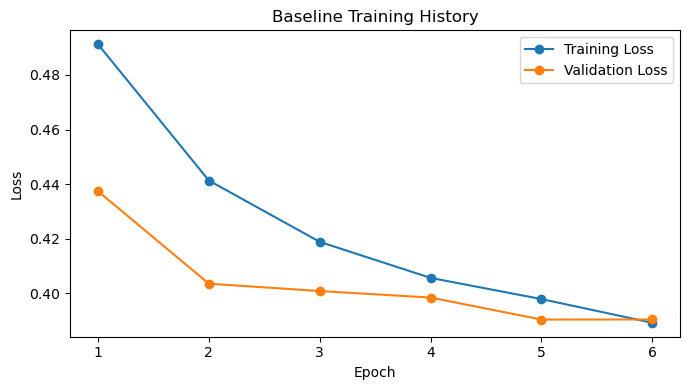

In [48]:
epochs = range(
    1,
    BASELINE_EPOCHS + 1
)

plt.figure(figsize=(7, 4))

plt.plot(
    epochs,
    baseline_history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    baseline_history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Training History")

plt.legend()
plt.tight_layout()
plt.show()

### 8.3 Fine-Tuning the Final ResNet Block

The baseline model trains only the final classification head while keeping the pretrained feature extractor frozen.

To adapt higher-level visual features to panoramic dental radiographs, the final ResNet block (`layer4`) is unfrozen together with the classification head.

A smaller learning rate is used during fine-tuning to reduce the risk of excessively modifying the pretrained weights.

The model checkpoint with the lowest validation loss is retained.

In [49]:
for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

In [50]:
trainable_parameters = [
    name
    for name, param in model.named_parameters()
    if param.requires_grad
]

print(
    "Number of trainable parameter tensors:",
    len(trainable_parameters)
)

print(trainable_parameters)

Number of trainable parameter tensors: 17
['layer4.0.conv1.weight', 'layer4.0.bn1.weight', 'layer4.0.bn1.bias', 'layer4.0.conv2.weight', 'layer4.0.bn2.weight', 'layer4.0.bn2.bias', 'layer4.0.downsample.0.weight', 'layer4.0.downsample.1.weight', 'layer4.0.downsample.1.bias', 'layer4.1.conv1.weight', 'layer4.1.bn1.weight', 'layer4.1.bn1.bias', 'layer4.1.conv2.weight', 'layer4.1.bn2.weight', 'layer4.1.bn2.bias', 'fc.weight', 'fc.bias']


In [51]:
finetune_optimizer = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-4
)

In [52]:
finetune_criterion = nn.BCEWithLogitsLoss()

In [53]:
FINETUNE_EPOCHS = 5

best_val_loss = float("inf")

finetune_history = {
    "train_loss": [],
    "val_loss": []
}

In [54]:
for epoch in range(FINETUNE_EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        finetune_criterion,
        finetune_optimizer,
        device
    )

    val_loss = evaluate_loss(
        model,
        valid_loader,
        finetune_criterion,
        device
    )

    finetune_history["train_loss"].append(
        train_loss
    )

    finetune_history["val_loss"].append(
        val_loss
    )

    print(
        f"Epoch {epoch + 1}/{FINETUNE_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            MODELS_DIR / "best_resnet18_finetuned.pth"
        )

        print("Best model saved.")

Epoch 1/5 | Train Loss: 0.3704 | Val Loss: 0.3383
Best model saved.
Epoch 2/5 | Train Loss: 0.2461 | Val Loss: 0.3275
Best model saved.
Epoch 3/5 | Train Loss: 0.1754 | Val Loss: 0.3327
Epoch 4/5 | Train Loss: 0.1315 | Val Loss: 0.3477
Epoch 5/5 | Train Loss: 0.1030 | Val Loss: 0.3575


In [55]:
model.load_state_dict(
    torch.load(
        MODELS_DIR /"best_resnet18_finetuned.pth",
        map_location=device,
        weights_only=True
    )
)

model.eval()

print("Best fine-tuned model loaded.")

Best fine-tuned model loaded.


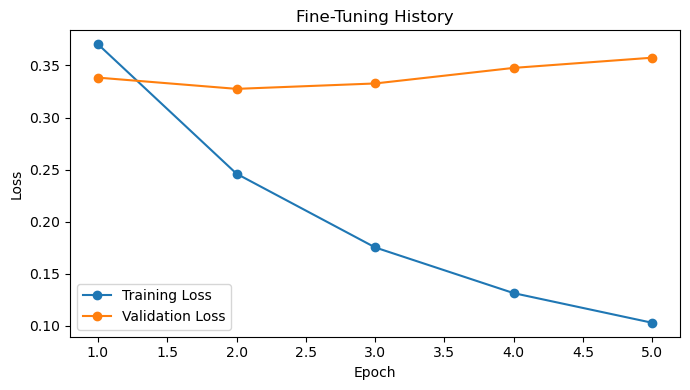

In [56]:
epochs = range(
    1,
    FINETUNE_EPOCHS + 1
)

plt.figure(figsize=(7, 4))

plt.plot(
    epochs,
    finetune_history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    finetune_history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fine-Tuning History")

plt.legend()
plt.tight_layout()
plt.show()

### 8.4 Class-Weighted Fine-Tuning

The training set is substantially imbalanced, with some dental findings occurring much less frequently than others.

To reduce the effect of class imbalance, positive-class weights are calculated from the training data and incorporated into `BCEWithLogitsLoss`.

Direct inverse-frequency weights can become extremely large for very rare classes. Therefore, the weights are stabilized using three steps:

1. Values below 1 are replaced by 1.
2. The square root of each weight is used to reduce extreme differences.
3. The final weights are capped at 10.

The weighted model is initialized from the best fine-tuned checkpoint and trained using a smaller learning rate.

In [57]:
positive_counts = train_df[
    label_columns
].sum()

negative_counts = (
    len(train_df) - positive_counts
)

raw_pos_weight = (
    negative_counts / positive_counts
)

pos_weight_df = pd.DataFrame({
    "Positive samples": positive_counts,
    "Negative samples": negative_counts,
    "Raw pos_weight": raw_pos_weight
})

pos_weight_df.round(3)

,Positive samples,Negative samples,Raw pos_weight
Implant,126,1249,9.913
Prosthetic restoration,540,835,1.546
Obturation,745,630,0.846
Endodontic treatment,782,593,0.758
Carious lesion,816,559,0.685
Bone resorption,438,937,2.139
Impacted tooth,327,1048,3.205
Apical periodontitis,521,854,1.639
Root fragment,416,959,2.305
Furcation lesion,190,1185,6.237


In [58]:
safe_pos_weight = np.maximum(
    raw_pos_weight.to_numpy(),
    1.0
)

safe_pos_weight = np.sqrt(
    safe_pos_weight
)

safe_pos_weight = np.clip(
    safe_pos_weight,
    None,
    10.0
)

pos_weight_tensor = torch.tensor(
    safe_pos_weight,
    dtype=torch.float32,
    device=device
)

In [59]:
weight_summary = pd.DataFrame({
    "Class": label_columns,
    "Raw weight": raw_pos_weight.values,
    "Final weight": safe_pos_weight
})

weight_summary.round(3)

,Class,Raw weight,Final weight
0,Implant,9.913,3.148
1,Prosthetic restoration,1.546,1.244
2,Obturation,0.846,1.000
3,Endodontic treatment,0.758,1.000
4,Carious lesion,0.685,1.000
5,Bone resorption,2.139,1.463
6,Impacted tooth,3.205,1.790
7,Apical periodontitis,1.639,1.280
8,Root fragment,2.305,1.518
9,Furcation lesion,6.237,2.497


In [60]:
weighted_criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_tensor
)

In [61]:
model.load_state_dict(
    torch.load(
        MODELS_DIR /"best_resnet18_finetuned.pth",
        map_location=device,
        weights_only=True
    )
)

<All keys matched successfully>

In [62]:
for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

In [63]:
weighted_optimizer = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=5e-5
)

In [64]:
def collect_probabilities(
    model,
    dataloader,
    device
):

    model.eval()

    all_probabilities = []
    all_targets = []

    with torch.no_grad():

        for images, targets in dataloader:

            images = images.to(device)

            outputs = model(images)

            probabilities = torch.sigmoid(
                outputs
            )

            all_probabilities.append(
                probabilities.cpu().numpy()
            )

            all_targets.append(
                targets.numpy()
            )

    all_probabilities = np.vstack(
        all_probabilities
    )

    all_targets = np.vstack(
        all_targets
    )

    return all_probabilities, all_targets

In [65]:
def compute_macro_auprc(
    targets,
    probabilities
):

    class_auprcs = []

    for class_idx in range(
        targets.shape[1]
    ):

        class_targets = targets[
            :,
            class_idx
        ]

        if class_targets.sum() == 0:
            continue

        class_probabilities = probabilities[
            :,
            class_idx
        ]

        auprc = average_precision_score(
            class_targets,
            class_probabilities
        )

        class_auprcs.append(
            auprc
        )

    return np.mean(class_auprcs)

In [66]:
WEIGHTED_EPOCHS = 5

best_macro_auprc = -np.inf

weighted_history = {
    "train_loss": [],
    "val_loss": [],
    "val_macro_auprc": []
}

In [67]:
for epoch in range(WEIGHTED_EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        weighted_criterion,
        weighted_optimizer,
        device
    )

    val_loss = evaluate_loss(
        model,
        valid_loader,
        weighted_criterion,
        device
    )

    val_probabilities, val_targets = (
        collect_probabilities(
            model,
            valid_loader,
            device
        )
    )

    val_macro_auprc = compute_macro_auprc(
        val_targets,
        val_probabilities
    )

    weighted_history["train_loss"].append(
        train_loss
    )

    weighted_history["val_loss"].append(
        val_loss
    )

    weighted_history[
        "val_macro_auprc"
    ].append(
        val_macro_auprc
    )

    print(
        f"Epoch {epoch + 1}/{WEIGHTED_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Macro AUPRC: {val_macro_auprc:.4f}"
    )

    if val_macro_auprc > best_macro_auprc:

        best_macro_auprc = val_macro_auprc

        torch.save(
            model.state_dict(),
            MODELS_DIR / "best_resnet18_weighted.pth"
        )

        print("Best weighted model saved.")

Epoch 1/5 | Train Loss: 0.2390 | Val Loss: 0.4158 | Val Macro AUPRC: 0.6641
Best weighted model saved.
Epoch 2/5 | Train Loss: 0.1749 | Val Loss: 0.4249 | Val Macro AUPRC: 0.6665
Best weighted model saved.
Epoch 3/5 | Train Loss: 0.1415 | Val Loss: 0.4389 | Val Macro AUPRC: 0.6606
Epoch 4/5 | Train Loss: 0.1232 | Val Loss: 0.4445 | Val Macro AUPRC: 0.6672
Best weighted model saved.
Epoch 5/5 | Train Loss: 0.1054 | Val Loss: 0.4647 | Val Macro AUPRC: 0.6605


In [68]:
model.load_state_dict(
    torch.load(
        MODELS_DIR /"best_resnet18_weighted.pth",
        map_location=device,
        weights_only=True
    )
)

model.eval()

print("Best weighted model loaded.")
print(f"Best validation Macro AUPRC: {best_macro_auprc:.4f}")

Best weighted model loaded.
Best validation Macro AUPRC: 0.6672


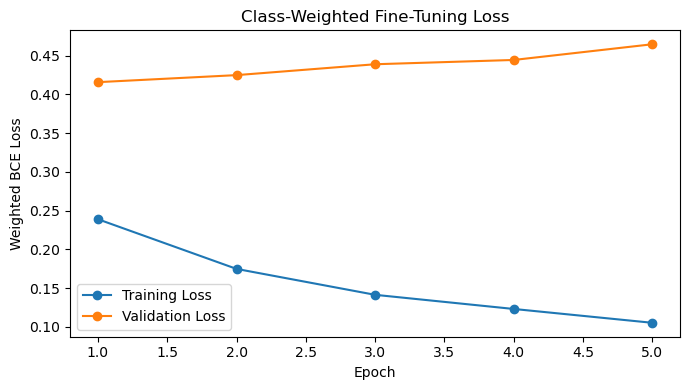

In [69]:
epochs = range(
    1,
    WEIGHTED_EPOCHS + 1
)

plt.figure(figsize=(7, 4))

plt.plot(
    epochs,
    weighted_history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    weighted_history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Weighted BCE Loss")
plt.title("Class-Weighted Fine-Tuning Loss")

plt.legend()
plt.tight_layout()
plt.show()

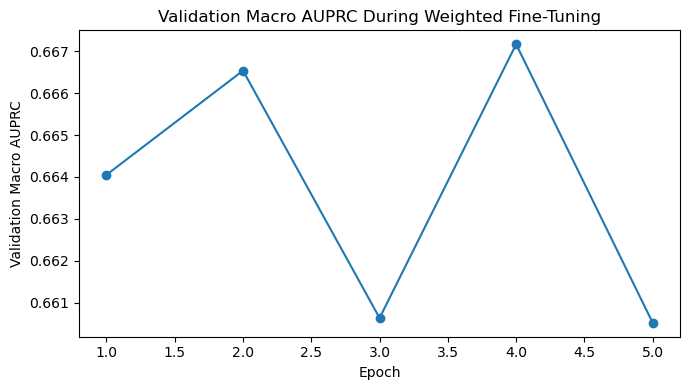

In [70]:
plt.figure(figsize=(7, 4))

plt.plot(
    epochs,
    weighted_history["val_macro_auprc"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Macro AUPRC")
plt.title("Validation Macro AUPRC During Weighted Fine-Tuning")

plt.tight_layout()
plt.show()

### 8.5 Training Summary

Three training strategies were explored:

1. **Baseline transfer learning**  
   Only the final classification layer was trained.

2. **Fine-tuning**  
   The final ResNet block (`layer4`) and classification head were jointly optimized using a smaller learning rate.

3. **Class-weighted fine-tuning**  
   Class-dependent positive weights were introduced to reduce the effect of class imbalance.  
   The model was initialized from the best fine-tuned checkpoint and trained with an even smaller learning rate.

For the standard fine-tuning stage, the checkpoint with the lowest validation loss was retained.

For class-weighted fine-tuning, model selection was based on **validation Macro AUPRC**, since the weighted loss itself is not directly comparable with the unweighted training objective.

The highest validation Macro AUPRC obtained during weighted fine-tuning was approximately **0.661**.

## 9. Threshold 

### 9.1 Threshold Optimization

The model produces one sigmoid probability for each of the 14 dental findings.

A fixed threshold of 0.5 is a common default, but it may not be optimal for all classes, particularly in an imbalanced multi-label dataset.

Therefore, class-specific decision thresholds are optimized using the **validation set only**.

For each dental finding, candidate thresholds are evaluated and the threshold producing the highest validation F1 score is selected.

The internal test and external validation sets are not used during threshold optimization.

In [71]:
model.load_state_dict(
    torch.load(
        MODELS_DIR /"best_resnet18_weighted.pth",
        map_location=device,
        weights_only=True
    )
)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [72]:
val_probabilities, val_targets = collect_probabilities(
    model,
    valid_loader,
    device
)

print(
    "Validation probabilities shape:",
    val_probabilities.shape
)

print(
    "Validation targets shape:",
    val_targets.shape
)

Validation probabilities shape: (153, 14)
Validation targets shape: (153, 14)


### 9.2 Global Threshold Comparison

Several global thresholds are first evaluated to illustrate how the decision threshold affects overall multi-label performance.

In [73]:
global_thresholds = [
    0.3,
    0.4,
    0.5,
    0.6,
    0.7
]

global_threshold_results = []

for threshold in global_thresholds:

    predictions = (
        val_probabilities >= threshold
    ).astype(int)

    micro_f1 = f1_score(
        val_targets,
        predictions,
        average="micro",
        zero_division=0
    )

    macro_f1 = f1_score(
        val_targets,
        predictions,
        average="macro",
        zero_division=0
    )

    global_threshold_results.append({
        "Threshold": threshold,
        "Micro F1": micro_f1,
        "Macro F1": macro_f1
    })

global_threshold_df = pd.DataFrame(
    global_threshold_results
)

global_threshold_df.round(4)

,Threshold,Micro F1,Macro F1
0,0.3,0.7168,0.5724
1,0.4,0.7325,0.5882
2,0.5,0.7151,0.5720
3,0.6,0.6996,0.5557
4,0.7,0.6646,0.5384


### 9.3 Per-Class Threshold Optimization

Because the 14 dental findings have different prevalence and prediction characteristics, a separate threshold is optimized for each class.

Thresholds from 0.05 to 0.95 are evaluated in steps of 0.01.

For classes with no positive validation samples, a threshold cannot be meaningfully optimized. In such cases, a default threshold of 0.5 is retained.

In [74]:
def optimize_thresholds(
    targets,
    probabilities,
    threshold_values=None
):

    if threshold_values is None:
        threshold_values = np.arange(
            0.05,
            0.96,
            0.01
        )

    best_thresholds = []
    best_f1_scores = []

    for class_idx in range(
        targets.shape[1]
    ):

        class_targets = targets[
            :,
            class_idx
        ]

        class_probabilities = probabilities[
            :,
            class_idx
        ]

        # Threshold optimization is not meaningful
        # when validation support is zero.
        if class_targets.sum() == 0:

            best_thresholds.append(
                np.nan
            )

            best_f1_scores.append(
                np.nan
            )

            continue

        best_threshold = 0.5
        best_f1 = -1.0

        for threshold in threshold_values:

            class_predictions = (
                class_probabilities >= threshold
            ).astype(int)

            current_f1 = f1_score(
                class_targets,
                class_predictions,
                zero_division=0
            )

            if current_f1 > best_f1:

                best_f1 = current_f1
                best_threshold = threshold

        best_thresholds.append(
            best_threshold
        )

        best_f1_scores.append(
            best_f1
        )

    return (
        np.array(best_thresholds),
        np.array(best_f1_scores)
    )

In [75]:
best_thresholds, best_val_f1 = (
    optimize_thresholds(
        val_targets,
        val_probabilities
    )
)

In [76]:
threshold_results_df = pd.DataFrame({
    "Class": label_columns,
    "Validation Support":
        val_targets.sum(axis=0).astype(int),
    "Best Threshold":
        best_thresholds,
    "Best Validation F1":
        best_val_f1
})

threshold_results_df.round(3)

,Class,Validation Support,Best Threshold,Best Validation F1
0,Implant,10,0.13,0.516
1,Prosthetic restoration,49,0.65,0.729
2,Obturation,80,0.28,0.795
3,Endodontic treatment,79,0.30,0.832
4,Carious lesion,108,0.18,0.876
5,Bone resorption,49,0.33,0.593
6,Impacted tooth,46,0.19,0.655
7,Apical periodontitis,45,0.43,0.557
8,Root fragment,43,0.54,0.759
9,Furcation lesion,15,0.13,0.375


In [77]:
final_thresholds = np.where(
    np.isnan(best_thresholds),
    0.5,
    best_thresholds
)

In [78]:
threshold_results_df[
    "Final Threshold"
] = final_thresholds

threshold_results_df.round(3)

,Class,Validation Support,Best Threshold,Best Validation F1,Final Threshold
0,Implant,10,0.13,0.516,0.13
1,Prosthetic restoration,49,0.65,0.729,0.65
2,Obturation,80,0.28,0.795,0.28
3,Endodontic treatment,79,0.30,0.832,0.30
4,Carious lesion,108,0.18,0.876,0.18
5,Bone resorption,49,0.33,0.593,0.33
6,Impacted tooth,46,0.19,0.655,0.19
7,Apical periodontitis,45,0.43,0.557,0.43
8,Root fragment,43,0.54,0.759,0.54
9,Furcation lesion,15,0.13,0.375,0.13


### 9.4 Validation Performance with Optimized Thresholds

In [79]:
val_predictions = (
    val_probabilities >= final_thresholds
).astype(int)

In [80]:
val_micro_f1 = f1_score(
    val_targets,
    val_predictions,
    average="micro",
    zero_division=0
)

In [81]:
val_macro_f1 = f1_score(
    val_targets,
    val_predictions,
    average="macro",
    zero_division=0
)

In [82]:
supported_mask = (
    val_targets.sum(axis=0) > 0
)

val_macro_f1_supported = f1_score(
    val_targets[:, supported_mask],
    val_predictions[:, supported_mask],
    average="macro",
    zero_division=0
)

In [83]:
print(
    f"Validation Micro F1: "
    f"{val_micro_f1:.4f}"
)

print(
    f"Validation Macro F1: "
    f"{val_macro_f1:.4f}"
)

print(
    f"Validation Macro F1 "
    f"(supported classes): "
    f"{val_macro_f1_supported:.4f}"
)

Validation Micro F1: 0.7306
Validation Macro F1: 0.6190
Validation Macro F1 (supported classes): 0.6667


The optimized thresholds are derived exclusively from the validation set.

These thresholds are now fixed and will be used without modification for evaluation on the internal test set and external validation set.

For classes without positive validation samples, threshold optimization is not possible; therefore, a default threshold of 0.5 is used.

## 10. Internal Test Evaluation

The final class-weighted model is evaluated on the predefined internal test set.

The class-specific thresholds optimized on the validation set are kept fixed and are applied directly to the test predictions.

No model parameters or decision thresholds are adjusted using the test set.

### 10.1 Collect Test Predictions

In [84]:
test_probabilities, test_targets = collect_probabilities(
    model,
    test_loader,
    device
)

print(
    "Test probabilities shape:",
    test_probabilities.shape
)

print(
    "Test targets shape:",
    test_targets.shape
)

Test probabilities shape: (100, 14)
Test targets shape: (100, 14)


In [85]:
test_predictions = (
    test_probabilities >= final_thresholds
).astype(int)

### 10.2 Overall Test Metrics

In [86]:
test_micro_f1 = f1_score(
    test_targets,
    test_predictions,
    average="micro",
    zero_division=0
)

test_macro_f1 = f1_score(
    test_targets,
    test_predictions,
    average="macro",
    zero_division=0
)

test_supported_mask = (
    test_targets.sum(axis=0) > 0
)

test_macro_f1_supported = f1_score(
    test_targets[:, test_supported_mask],
    test_predictions[:, test_supported_mask],
    average="macro",
    zero_division=0
)

print(
    f"Test Micro F1: "
    f"{test_micro_f1:.4f}"
)

print(
    f"Test Macro F1: "
    f"{test_macro_f1:.4f}"
)

print(
    f"Test Macro F1 "
    f"(supported classes): "
    f"{test_macro_f1_supported:.4f}"
)

Test Micro F1: 0.6322
Test Macro F1: 0.4907
Test Macro F1 (supported classes): 0.5284


### 10.3 Per-Class Precision, Recall and F1

In [87]:
precision, recall, f1, support = (
    precision_recall_fscore_support(
        test_targets,
        test_predictions,
        average=None,
        zero_division=0
    )
)

test_metrics_df = pd.DataFrame({
    "Class": label_columns,
    "Support": support.astype(int),
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "Threshold": final_thresholds
})

test_metrics_df.round(3)

,Class,Support,Precision,Recall,F1,Threshold
0,Implant,11,0.216,0.727,0.333,0.13
1,Prosthetic restoration,40,0.750,0.675,0.711,0.65
2,Obturation,72,0.800,0.889,0.842,0.28
3,Endodontic treatment,67,0.704,0.851,0.770,0.30
4,Carious lesion,43,0.500,0.907,0.645,0.18
5,Bone resorption,22,0.405,0.682,0.508,0.33
6,Impacted tooth,24,0.380,0.792,0.514,0.19
7,Apical periodontitis,40,0.458,0.275,0.344,0.43
8,Root fragment,13,0.389,0.538,0.452,0.54
9,Furcation lesion,9,0.111,0.222,0.148,0.13


### AUROC and AUPRC Interpretation

Threshold-independent performance also varies considerably across classes.

Several findings, including Surgical device, Orthodontic device, and Obturation, show relatively strong discrimination. In contrast, rare findings such as Furcation lesion and Apical surgery have substantially lower AUPRC values.

Because the dataset is highly imbalanced, AUPRC is particularly useful for interpreting performance on rare positive classes.

Root resorption has no positive samples in the internal test set, so AUROC and AUPRC cannot be computed for this class.

### 10.4 Per-Class AUROC and AUPRC

In [88]:
test_auc_results = []

for class_idx, class_name in enumerate(
    label_columns
):

    y_true = test_targets[
        :,
        class_idx
    ]

    y_prob = test_probabilities[
        :,
        class_idx
    ]

    support = int(
        y_true.sum()
    )

    if len(np.unique(y_true)) < 2:

        auroc = np.nan
        auprc = np.nan

    else:

        auroc = roc_auc_score(
            y_true,
            y_prob
        )

        auprc = average_precision_score(
            y_true,
            y_prob
        )

    test_auc_results.append({
        "Class": class_name,
        "Support": support,
        "AUROC": auroc,
        "AUPRC": auprc
    })

test_auc_df = pd.DataFrame(
    test_auc_results
)

test_auc_df.round(3)

,Class,Support,AUROC,AUPRC
0,Implant,11,0.793,0.345
1,Prosthetic restoration,40,0.857,0.847
2,Obturation,72,0.789,0.906
3,Endodontic treatment,67,0.692,0.847
4,Carious lesion,43,0.756,0.713
5,Bone resorption,22,0.780,0.551
6,Impacted tooth,24,0.772,0.590
7,Apical periodontitis,40,0.562,0.490
8,Root fragment,13,0.867,0.404
9,Furcation lesion,9,0.587,0.127


### Interpretation

The class-weighted model achieved a Micro F1 score of **0.675** on the internal test set.

Performance varied substantially across dental findings. Common findings such as Obturation and Endodontic treatment achieved relatively strong F1 scores, while several rare findings showed considerably lower performance.

Metrics for very low-support classes should be interpreted cautiously. In particular, Apical surgery contains only two positive test samples, while Root resorption has no positive samples in the internal test set and therefore cannot be meaningfully evaluated on this split.

The internal test results are reported using thresholds selected exclusively on the validation set.

Per-class results should be interpreted together with class support, since metrics for very rare findings may be unstable or unavailable when no positive test samples are present.

## 11. External Validation

The final model is further evaluated on the additional external validation set.

This dataset is not used for model training, model selection, or threshold optimization.

The model weights and class-specific thresholds selected using the training and validation sets are kept fixed throughout external evaluation.

This evaluation provides an additional assessment of how well the model generalizes beyond the main dataset splits.

In [89]:
external_dir = (
    DATA_DIR
    / "test_alte_cabinete"
    / "Ext-validation"
)

external_images_dir = (
    external_dir / "images"
)

external_labels_dir = (
    external_dir / "labels"
)

### 11.1 External Dataset Preparation

The external YOLO annotations are converted into the same image-level multi-label representation used for the internal dataset.

In [90]:
external_records = build_records(
    external_labels_dir,
    external_images_dir
)

external_df = records_to_dataframe(
    external_records,
    label_columns
)

print(
    "External dataset shape:",
    external_df.shape
)

External dataset shape: (180, 15)


In [91]:
external_df.head()

,image,Implant,Prosthetic restoration,Obturation,Endodontic treatment,Carious lesion,Bone resorption,Impacted tooth,Apical periodontitis,Root fragment,Furcation lesion,Apical surgery,Root resorption,Orthodontic device,Surgical device
0,1.jpg,0,1,1,1,1,0,1,1,0,0,0,0,0,0
1,10.jpg,0,0,1,0,1,0,0,0,0,0,0,0,0,0
2,100.jpg,0,0,1,0,0,0,0,0,0,0,0,0,0,0
3,101.jpg,0,0,1,1,1,0,1,0,0,0,0,0,0,0
4,102.jpg,0,0,0,0,0,0,1,0,0,0,0,0,0,0


In [92]:
external_dataset = OPGDataset(
    dataframe=external_df,
    images_dir=external_images_dir,
    label_columns=label_columns,
    transform=transform
)

external_loader = DataLoader(
    external_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(
    "External samples:",
    len(external_dataset)
)

External samples: 180


In [93]:
external_images, external_targets_batch = next(
    iter(external_loader)
)

print(
    "Image batch shape:",
    external_images.shape
)

print(
    "Target batch shape:",
    external_targets_batch.shape
)

Image batch shape: torch.Size([16, 3, 224, 224])
Target batch shape: torch.Size([16, 14])


### 11.2 External Predictions

The fixed class-specific thresholds optimized on the validation set are applied directly to the external predictions.

No threshold adjustment is performed using the external validation data.

In [94]:
external_probabilities, external_targets = (
    collect_probabilities(
        model,
        external_loader,
        device
    )
)

print(
    "External probabilities shape:",
    external_probabilities.shape
)

print(
    "External targets shape:",
    external_targets.shape
)

External probabilities shape: (180, 14)
External targets shape: (180, 14)


In [95]:
external_predictions = (
    external_probabilities >= final_thresholds
).astype(int)

### 11.3 Overall External Performance

In [96]:
external_micro_f1 = f1_score(
    external_targets,
    external_predictions,
    average="micro",
    zero_division=0
)

external_macro_f1 = f1_score(
    external_targets,
    external_predictions,
    average="macro",
    zero_division=0
)

external_supported_mask = (
    external_targets.sum(axis=0) > 0
)

external_macro_f1_supported = f1_score(
    external_targets[:, external_supported_mask],
    external_predictions[:, external_supported_mask],
    average="macro",
    zero_division=0
)

print(
    f"External Micro F1: "
    f"{external_micro_f1:.4f}"
)

print(
    f"External Macro F1: "
    f"{external_macro_f1:.4f}"
)

print(
    f"External Macro F1 "
    f"(supported classes): "
    f"{external_macro_f1_supported:.4f}"
)

External Micro F1: 0.5976
External Macro F1: 0.3559
External Macro F1 (supported classes): 0.3833


### 11.4 Per-Class External Metrics

In [97]:
precision, recall, f1, support = (
    precision_recall_fscore_support(
        external_targets,
        external_predictions,
        average=None,
        zero_division=0
    )
)

external_metrics_df = pd.DataFrame({
    "Class": label_columns,
    "Support": support.astype(int),
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "Threshold": final_thresholds
})

external_metrics_df.round(3)

,Class,Support,Precision,Recall,F1,Threshold
0,Implant,5,0.029,0.200,0.050,0.13
1,Prosthetic restoration,82,0.735,0.439,0.550,0.65
2,Obturation,130,0.780,0.954,0.858,0.28
3,Endodontic treatment,120,0.748,0.767,0.757,0.30
4,Carious lesion,101,0.561,1.000,0.719,0.18
5,Bone resorption,79,0.575,0.532,0.553,0.33
6,Impacted tooth,51,0.369,0.804,0.506,0.19
7,Apical periodontitis,48,0.206,0.292,0.241,0.43
8,Root fragment,33,0.463,0.576,0.514,0.54
9,Furcation lesion,12,0.074,0.333,0.121,0.13


### 11.5 External AUROC and AUPRC

In [98]:
external_auc_results = []

for class_idx, class_name in enumerate(
    label_columns
):

    y_true = external_targets[
        :,
        class_idx
    ]

    y_prob = external_probabilities[
        :,
        class_idx
    ]

    support = int(
        y_true.sum()
    )

    if len(np.unique(y_true)) < 2:

        auroc = np.nan
        auprc = np.nan

    else:

        auroc = roc_auc_score(
            y_true,
            y_prob
        )

        auprc = average_precision_score(
            y_true,
            y_prob
        )

    external_auc_results.append({
        "Class": class_name,
        "Support": support,
        "AUROC": auroc,
        "AUPRC": auprc
    })

external_auc_df = pd.DataFrame(
    external_auc_results
)

external_auc_df.round(3)

,Class,Support,AUROC,AUPRC
0,Implant,5,0.538,0.037
1,Prosthetic restoration,82,0.744,0.739
2,Obturation,130,0.699,0.828
3,Endodontic treatment,120,0.703,0.822
4,Carious lesion,101,0.563,0.612
5,Bone resorption,79,0.702,0.641
6,Impacted tooth,51,0.677,0.472
7,Apical periodontitis,48,0.468,0.293
8,Root fragment,33,0.768,0.463
9,Furcation lesion,12,0.569,0.125


The external validation set is evaluated without modifying the trained model or the validation-derived thresholds.

Differences between internal and external performance are therefore interpreted as generalization differences rather than as an opportunity for additional model tuning.

Per-class results are interpreted together with class support because metrics for findings with very few positive external samples can be highly unstable.

## 12. Error Analysis

To better understand the external validation results, prediction errors are analyzed at the class level.

For each dental finding, the numbers of true positives (TP), false positives (FP), false negatives (FN), and true negatives (TN) are calculated.

This analysis helps distinguish between classes that are mainly affected by missed findings and classes that are frequently overpredicted.

### 12.1 Class-Level Error Counts

In [99]:
error_results = []

for class_idx, class_name in enumerate(label_columns):

    y_true = external_targets[:, class_idx]
    y_pred = external_predictions[:, class_idx]

    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tn = np.sum((y_true == 0) & (y_pred == 0))

    positive_count = tp + fn
    negative_count = fp + tn

    miss_rate = (
        fn / positive_count
        if positive_count > 0
        else np.nan
    )

    false_positive_rate = (
        fp / negative_count
        if negative_count > 0
        else np.nan
    )

    error_results.append({
        "Class": class_name,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Miss Rate": miss_rate,
        "False Positive Rate": false_positive_rate
    })

external_error_df = pd.DataFrame(
    error_results
)

external_error_df.round(3)

,Class,TP,FP,FN,TN,Miss Rate,False Positive Rate
0,Implant,1,34,4,141,0.800,0.194
1,Prosthetic restoration,36,13,46,85,0.561,0.133
2,Obturation,124,35,6,15,0.046,0.700
3,Endodontic treatment,92,31,28,29,0.233,0.517
4,Carious lesion,101,79,0,0,0.000,1.000
5,Bone resorption,42,31,37,70,0.468,0.307
6,Impacted tooth,41,70,10,59,0.196,0.543
7,Apical periodontitis,14,54,34,78,0.708,0.409
8,Root fragment,19,22,14,125,0.424,0.150
9,Furcation lesion,4,50,8,118,0.667,0.298


The class-level error analysis provides information that is not visible from F1 score alone.

A high **miss rate** indicates that the model frequently fails to detect a finding when it is actually present.

A high **false positive rate** indicates that the model tends to predict the finding in OPGs where it is not annotated.

### Error Pattern Interpretation

The external error analysis reveals different failure patterns across classes.

Some findings, such as Carious lesion and Obturation, have very low miss rates but high false positive rates, indicating a tendency toward overprediction.

Other findings, such as Bone resorption, show the opposite pattern, with relatively few false positives but a high proportion of missed positive cases.

Apical periodontitis shows both a high miss rate and a high false positive rate, suggesting that this class is particularly challenging for the model on the external dataset.

### 12.2 Focused Error Analysis: Apical Periodontitis

Apical periodontitis is selected for deeper analysis because it has substantial external support and shows both frequent missed detections and false positive predictions.

False positive and false negative OPGs are identified for visual inspection.

In [100]:
target_class = 7

apical_true = external_targets[:, target_class]
apical_pred = external_predictions[:, target_class]

tp_indices = np.where(
    (apical_true == 1) &
    (apical_pred == 1)
)[0]

fp_indices = np.where(
    (apical_true == 0) &
    (apical_pred == 1)
)[0]

fn_indices = np.where(
    (apical_true == 1) &
    (apical_pred == 0)
)[0]

print("TP count:", len(tp_indices))
print("FP count:", len(fp_indices))
print("FN count:", len(fn_indices))

TP count: 14
FP count: 54
FN count: 34


In [101]:
external_df_reset = external_df.reset_index(
    drop=True
)

fp_image_names = external_df_reset.loc[
    fp_indices,
    "image"
].tolist()

fn_image_names = external_df_reset.loc[
    fn_indices,
    "image"
].tolist()

print(
    "First 10 FP images:",
    fp_image_names[:10]
)

print(
    "First 10 FN images:",
    fn_image_names[:10]
)

First 10 FP images: ['103.jpg', '104.jpg', '11.jpg', '113.jpg', '120.jpg', '128.jpg', '129.jpg', '13.jpg', '132.jpg', '136.jpg']
First 10 FN images: ['1.jpg', '110.jpg', '111.jpg', '115.jpg', '116.jpg', '117.jpg', '12.jpg', '124.jpg', '126.jpg', '127.jpg']


### 12.3 Visual Inspection of False Positives and False Negatives

Representative false positive and false negative OPGs are visually inspected to better understand the model's failure modes.

The predicted probability for Apical periodontitis is displayed together with the fixed validation-derived threshold.

In [102]:
def show_error_examples(
    indices,
    error_type,
    class_idx=7,
    n=3
):
    selected_indices = indices[:n]

    fig, axes = plt.subplots(
        1,
        n,
        figsize=(15, 5)
    )

    for ax, idx in zip(
        axes,
        selected_indices
    ):
        image_name = external_df_reset.loc[
            idx,
            "image"
        ]

        image_path = (
            external_images_dir / image_name
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        probability = external_probabilities[
            idx,
            class_idx
        ]

        threshold = final_thresholds[
            class_idx
        ]

        ground_truth = int(
            external_targets[
                idx,
                class_idx
            ]
        )

        prediction = int(
            external_predictions[
                idx,
                class_idx
            ]
        )

        ax.imshow(image)
        ax.axis("off")

        ax.set_title(
            f"{image_name}\n"
            f"GT={ground_truth} | Pred={prediction}\n"
            f"P={probability:.3f} | T={threshold:.2f}"
        )

    plt.suptitle(
        f"Apical Periodontitis — {error_type}"
    )

    plt.tight_layout()
    plt.show()

In [ ]:
show_error_examples(
    fp_indices,
    error_type="False Positives"
)

In [ ]:
show_error_examples(
    fn_indices,
    error_type="False Negatives"
)

### 12.4 Ground-Truth Localization of False Negatives

The original YOLO bounding-box annotations are used to visualize the locations of Apical periodontitis findings in selected false negative OPGs.

These bounding boxes were not used during classifier training; they are used here only for post-hoc error analysis.

In [105]:
from matplotlib.patches import Rectangle


def show_apical_boxes(
    indices,
    class_idx=7,
    n=3
):
    selected_indices = indices[:n]

    fig, axes = plt.subplots(
        1,
        n,
        figsize=(15, 5)
    )

    for ax, idx in zip(
        axes,
        selected_indices
    ):
        image_name = external_df_reset.loc[
            idx,
            "image"
        ]

        image_path = (
            external_images_dir / image_name
        )

        label_path = (
            external_labels_dir
            / f"{Path(image_name).stem}.txt"
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        width, height = image.size

        ax.imshow(image)

        with open(label_path, "r") as f:

            for line in f:

                parts = line.split()

                label_class = int(parts[0])

                if label_class != class_idx:
                    continue

                x_center = float(parts[1])
                y_center = float(parts[2])
                box_width = float(parts[3])
                box_height = float(parts[4])

                x = (
                    x_center - box_width / 2
                ) * width

                y = (
                    y_center - box_height / 2
                ) * height

                box_width_px = (
                    box_width * width
                )

                box_height_px = (
                    box_height * height
                )

                rectangle = Rectangle(
                    (x, y),
                    box_width_px,
                    box_height_px,
                    fill=False,
                    linewidth=2
                )

                ax.add_patch(rectangle)

        probability = external_probabilities[
            idx,
            class_idx
        ]

        ax.set_title(
            f"{image_name}\n"
            f"FN | P={probability:.3f}"
        )

        ax.axis("off")

    plt.suptitle(
        "Ground-Truth Apical Periodontitis Boxes in False Negatives"
    )

    plt.tight_layout()
    plt.show()

In [ ]:
show_apical_boxes(
    fn_indices
)

### 12.5 Bounding-Box Size Analysis

To investigate whether missed Apical periodontitis findings tend to be smaller, the normalized bounding-box areas are compared between true positive and false negative OPGs.

For each positive OPG, the largest Apical periodontitis bounding box is used as a simple measure of lesion size.

In [107]:
def get_class_box_areas(
    label_path,
    target_class=7
):
    areas = []

    with open(label_path, "r") as f:

        for line in f:

            parts = line.split()

            class_id = int(parts[0])

            if class_id != target_class:
                continue

            width = float(parts[3])
            height = float(parts[4])

            area = width * height

            areas.append(area)

    return areas

In [108]:
def get_max_box_area_for_indices(
    indices,
    class_idx=7
):
    max_areas = []

    for idx in indices:

        image_name = external_df_reset.loc[
            idx,
            "image"
        ]

        label_path = (
            external_labels_dir
            / f"{Path(image_name).stem}.txt"
        )

        areas = get_class_box_areas(
            label_path,
            target_class=class_idx
        )

        if len(areas) > 0:
            max_areas.append(
                max(areas)
            )

    return np.array(max_areas)

In [109]:
tp_box_areas = get_max_box_area_for_indices(
    tp_indices
)

fn_box_areas = get_max_box_area_for_indices(
    fn_indices
)

In [110]:
print(
    "TP count:",
    len(tp_box_areas)
)

print(
    "FN count:",
    len(fn_box_areas)
)

print(
    "TP median area:",
    np.median(tp_box_areas)
)

print(
    "FN median area:",
    np.median(fn_box_areas)
)

print(
    "TP mean area:",
    np.mean(tp_box_areas)
)

print(
    "FN mean area:",
    np.mean(fn_box_areas)
)

TP count: 14
FN count: 34
TP median area: 0.0025335889344999998
FN median area: 0.002527217456
TP mean area: 0.0026321992558571428
FN mean area: 0.0028586066502058823


The bounding-box size distributions of true positive and false negative cases are very similar.

False negative cases have only slightly smaller mean and median bounding-box areas than true positive cases.

Therefore, lesion size alone does not appear to provide a strong explanation for the missed Apical periodontitis predictions in the external validation set.

### 12.6 Number of Apical Periodontitis Annotations per OPG

The number of Apical periodontitis bounding boxes is compared between true positive and false negative OPGs to investigate whether images containing multiple annotated lesions are easier for the classifier to recognize.

In [111]:
def count_class_boxes(
    label_path,
    target_class=7
):
    count = 0

    with open(label_path, "r") as f:

        for line in f:

            parts = line.split()

            class_id = int(parts[0])

            if class_id == target_class:
                count += 1

    return count

In [112]:
def get_box_counts_for_indices(
    indices,
    class_idx=7
):
    counts = []

    for idx in indices:

        image_name = external_df_reset.loc[
            idx,
            "image"
        ]

        label_path = (
            external_labels_dir
            / f"{Path(image_name).stem}.txt"
        )

        counts.append(
            count_class_boxes(
                label_path,
                target_class=class_idx
            )
        )

    return np.array(counts)

In [113]:
tp_box_counts = get_box_counts_for_indices(
    tp_indices
)

fn_box_counts = get_box_counts_for_indices(
    fn_indices
)

print(
    "TP mean box count:",
    tp_box_counts.mean()
)

print(
    "FN mean box count:",
    fn_box_counts.mean()
)

print(
    "TP median box count:",
    np.median(tp_box_counts)
)

print(
    "FN median box count:",
    np.median(fn_box_counts)
)

print(
    "TP counts:",
    tp_box_counts
)

print(
    "FN counts:",
    fn_box_counts
)

TP mean box count: 2.9285714285714284
FN mean box count: 1.911764705882353
TP median box count: 2.0
FN median box count: 2.0
TP counts: [2 9 4 3 2 4 1 2 2 6 2 1 1 2]
FN counts: [3 2 3 2 2 1 4 1 3 2 3 2 1 4 2 1 1 2 1 2 1 2 1 1 3 1 1 2 2 1 2 4 1 1]


True positive OPGs contain more Apical periodontitis annotations on average than false negative OPGs (2.74 vs. 1.86 boxes per image).

However, both groups have the same median of two annotations, and several high-count true positive cases increase the TP mean.

Therefore, the number of annotated findings may contribute to recognition, but the observed difference is descriptive and should not be interpreted as a definitive explanation for false negative predictions.

### 12.7 Spatial Distribution of Apical Periodontitis

The normalized bounding-box centers are compared between true positive and false negative cases to investigate whether missed findings are concentrated in particular regions of the panoramic image.

This analysis describes image-coordinate locations only and does not assume that simple image regions correspond exactly to specific anatomical regions.

In [114]:
def get_class_centers(
    label_path,
    target_class=7
):
    centers = []

    with open(label_path, "r") as f:

        for line in f:

            parts = line.split()
            class_id = int(parts[0])

            if class_id == target_class:

                x_center = float(parts[1])
                y_center = float(parts[2])

                centers.append(
                    (x_center, y_center)
                )

    return centers

In [115]:
tp_centers = []
fn_centers = []

for idx in tp_indices:

    image_name = external_df_reset.loc[
        idx,
        "image"
    ]

    label_path = (
        external_labels_dir
        / f"{Path(image_name).stem}.txt"
    )

    tp_centers.extend(
        get_class_centers(label_path)
    )


for idx in fn_indices:

    image_name = external_df_reset.loc[
        idx,
        "image"
    ]

    label_path = (
        external_labels_dir
        / f"{Path(image_name).stem}.txt"
    )

    fn_centers.extend(
        get_class_centers(label_path)
    )

In [116]:
tp_centers_np = np.array(tp_centers)
fn_centers_np = np.array(fn_centers)

In [117]:
print(
    "TP mean x:",
    tp_centers_np[:, 0].mean()
)

print(
    "FN mean x:",
    fn_centers_np[:, 0].mean()
)

print(
    "TP mean y:",
    tp_centers_np[:, 1].mean()
)

print(
    "FN mean y:",
    fn_centers_np[:, 1].mean()
)

print(
    "TP upper-half ratio:",
    np.mean(
        tp_centers_np[:, 1] < 0.5
    )
)

print(
    "FN upper-half ratio:",
    np.mean(
        fn_centers_np[:, 1] < 0.5
    )
)

TP mean x: 0.4960212195121951
FN mean x: 0.49268784615384614
TP mean y: 0.6198416585365855
FN mean y: 0.6185765846153847
TP upper-half ratio: 0.2926829268292683
FN upper-half ratio: 0.36923076923076925


The spatial distributions of Apical periodontitis annotations are similar between true positive and false negative cases.

The mean horizontal and vertical box-center coordinates differ only slightly between the two groups, and the proportion of annotations located in the upper half of the image is also comparable.

Therefore, there is no clear evidence that false negative predictions are concentrated in a specific image region.

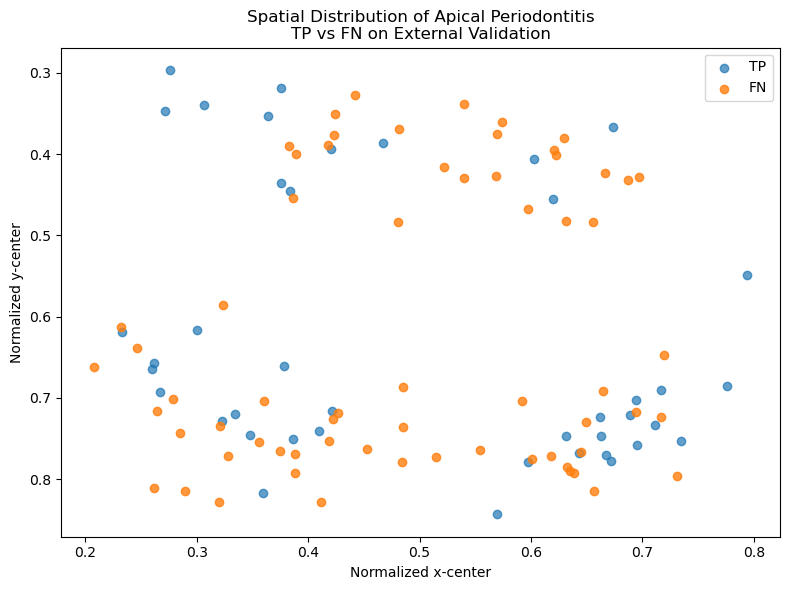

In [118]:
plt.figure(figsize=(8, 6))

plt.scatter(
    tp_centers_np[:, 0],
    tp_centers_np[:, 1],
    alpha=0.7,
    label="TP"
)

plt.scatter(
    fn_centers_np[:, 0],
    fn_centers_np[:, 1],
    alpha=0.8,
    label="FN"
)

plt.xlabel("Normalized x-center")
plt.ylabel("Normalized y-center")

plt.title(
    "Spatial Distribution of Apical Periodontitis\n"
    "TP vs FN on External Validation"
)

plt.gca().invert_yaxis()

plt.legend()
plt.tight_layout()
plt.show()

## 13. Inference

The final class-weighted ResNet18 model and the validation-derived class-specific thresholds are packaged into a single checkpoint for inference.

During inference:

1. An OPG is loaded and preprocessed using the same transformation used during training.
2. The model produces 14 logits.
3. Sigmoid converts the logits into probabilities.
4. The fixed class-specific thresholds convert the probabilities into binary predictions.

No threshold optimization is performed during inference.

In [119]:
model.load_state_dict(
    torch.load(
        MODELS_DIR /"best_resnet18_weighted.pth",
        map_location=device,
        weights_only=True
    )
)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [120]:
final_checkpoint = {
    "model_state_dict": model.state_dict(),
    "thresholds": torch.tensor(
        final_thresholds,
        dtype=torch.float32
    ),
    "class_names": label_columns,
    "image_size": IMAGE_SIZE
}

torch.save(
    final_checkpoint,
    MODELS_DIR / "opg_resnet18_final.pth"
)

print("Final model checkpoint saved.")

Final model checkpoint saved.


### 13.2 Loading the Model for Inference

In [121]:
checkpoint = torch.load(
    MODELS_DIR / "opg_resnet18_final.pth",
    map_location=device,
    weights_only=True
)

In [122]:
inference_model = models.resnet18(
    weights=None
)

inference_model.fc = nn.Linear(
    inference_model.fc.in_features,
    NUM_CLASSES
)

inference_model.load_state_dict(
    checkpoint["model_state_dict"]
)

inference_model = inference_model.to(device)
inference_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [123]:
inference_class_names = checkpoint[
    "class_names"
]

inference_thresholds = checkpoint[
    "thresholds"
].numpy()

inference_image_size = checkpoint[
    "image_size"
]

### 13.3 Inference Preprocessing

Inference must use the same image preprocessing applied during model training.

In [124]:
inference_transform = transforms.Compose([
    transforms.Resize(
        (
            inference_image_size,
            inference_image_size
        )
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

### 13.4 Prediction Function

In [125]:
def predict_opg(image_path):

    image = Image.open(
        image_path
    ).convert("RGB")

    image_tensor = inference_transform(
        image
    )

    image_tensor = (
        image_tensor
        .unsqueeze(0)
        .to(device)
    )

    with torch.no_grad():

        outputs = inference_model(
            image_tensor
        )

        probabilities = torch.sigmoid(
            outputs
        )

    probabilities = (
        probabilities
        .cpu()
        .numpy()[0]
    )

    predictions = (
        probabilities >= inference_thresholds
    ).astype(int)

    results = pd.DataFrame({
        "Finding": inference_class_names,
        "Probability": probabilities,
        "Threshold": inference_thresholds,
        "Prediction": predictions
    })

    return results

In [126]:
example_image_path = (
    test_images_dir /
    test_df.iloc[0]["image"]
)

prediction_results = predict_opg(
    example_image_path
)

prediction_results.round(3)

,Finding,Probability,Threshold,Prediction
0,Implant,0.072,0.13,0
1,Prosthetic restoration,0.187,0.65,0
2,Obturation,0.965,0.28,1
3,Endodontic treatment,0.278,0.30,0
4,Carious lesion,0.711,0.18,1
5,Bone resorption,0.151,0.33,0
6,Impacted tooth,0.774,0.19,1
7,Apical periodontitis,0.015,0.43,0
8,Root fragment,0.145,0.54,0
9,Furcation lesion,0.055,0.13,0


In [127]:
positive_predictions = (
    prediction_results[
        prediction_results[
            "Prediction"
        ] == 1
    ]
)

positive_predictions.round(3)

,Finding,Probability,Threshold,Prediction
2,Obturation,0.965,0.28,1
4,Carious lesion,0.711,0.18,1
6,Impacted tooth,0.774,0.19,1


The inference function returns the predicted probability, class-specific threshold, and binary prediction for each of the 14 dental findings.

The reported predictions are image-level findings and do not indicate the spatial location of abnormalities within the OPG.

## 14. Final Results and Project Summary

This project developed an image-level multi-label classification pipeline for detecting 14 dental findings in panoramic dental radiographs.

A pretrained ResNet18 was progressively adapted using:

1. Baseline transfer learning with only the classification head trained
2. Fine-tuning of `layer4` and the classification head
3. Class-weighted fine-tuning to address class imbalance
4. Per-class decision threshold optimization using the validation set

The final model was evaluated on both the predefined internal test set and an additional external validation set.

### 14.1 Overall Performance

In [128]:
summary_results = pd.DataFrame({
    "Dataset": [
        "Internal Test",
        "External Validation"
    ],

    "Micro F1": [
        test_micro_f1,
        external_micro_f1
    ],

    "Macro F1": [
        test_macro_f1,
        external_macro_f1
    ],

    "Macro F1 (Supported Classes)": [
        test_macro_f1_supported,
        external_macro_f1_supported
    ]
})

summary_results.round(3)

,Dataset,Micro F1,Macro F1,Macro F1 (Supported Classes)
0,Internal Test,0.632,0.491,0.528
1,External Validation,0.598,0.356,0.383


The model achieves stronger performance on the internal test set than on the external validation set.

The reduction in external Macro F1 is larger than the reduction in Micro F1, indicating that external performance degradation is not uniform across classes.

Several frequently represented findings retain relatively strong performance externally, while some less stable classes show substantial decreases.

The external results demonstrate that model generalization varies considerably across dental findings.

### 14.2 Important Per-Class Observations

Several class-specific patterns are important when interpreting the results:

- **Obturation** and **Endodontic treatment** maintain relatively strong performance on both internal and external evaluation.
- **Surgical device** and **Orthodontic device** perform strongly on the internal test set, but their external supports are extremely small, making external estimates unstable.
- **Apical periodontitis** shows substantially weaker external performance and was therefore selected for focused error analysis.
- **Apical surgery** has very few positive samples, so its evaluation metrics are highly unstable.
- **Root resorption** has no positive samples in the validation, internal test, or external validation sets and therefore cannot be meaningfully evaluated on these splits.

### 14.3 Error Analysis Summary

Focused error analysis was performed for Apical periodontitis on the external validation set.

The analysis showed that:

- Both false positives and false negatives occur frequently.
- False negative cases did not show a clear difference in bounding-box size compared with true positive cases.
- True positive OPGs contained more annotated Apical periodontitis boxes on average, although the median number of boxes was the same for true positive and false negative cases.
- The spatial distributions of true positive and false negative annotations were broadly similar.

These observations suggest that no single simple property such as lesion size or image location fully explains the external errors.

### 14.4 Limitations

This project has several important limitations:

- The task is image-level classification and does not localize individual dental findings.
- Panoramic radiographs are directly resized to `224 × 224`, which changes their original aspect ratio and may introduce geometric distortion.
- The dataset is highly imbalanced, with some findings represented by very few positive samples.
- Root resorption cannot be evaluated because no positive samples are available in the validation, internal test, or external validation splits.
- Metrics for very low-support classes should be interpreted cautiously.
- The class weights used during training were stabilized using a heuristic square-root transformation and an upper cap.
- Decision thresholds were optimized for F1 score on the validation set and may not represent the optimal operating point for every clinical application.
- External performance is lower for several findings, indicating that further evaluation on independent datasets is needed.

### 14.5 Conclusion

This project demonstrates a complete multi-label deep learning pipeline for image-level analysis of panoramic dental radiographs.

Class-weighted fine-tuning and class-specific decision thresholds provided a practical approach for handling the strongly imbalanced label distribution.

The final model achieved a Micro F1 score of approximately **0.675** on the internal test set and **0.625** on the external validation set.

External validation revealed substantial variation in generalization across dental findings, emphasizing the importance of class-level evaluation rather than relying only on aggregate performance metrics.

Future work could investigate alternative image preprocessing strategies, stronger data augmentation, different pretrained architectures, calibration methods, and localization-based approaches such as object detection or segmentation.

In [129]:
summary_results.to_csv(
    RESULTS_DIR / "summary_results.csv",
    index=False
)

test_metrics_df.to_csv(
    RESULTS_DIR / "internal_test_per_class_results.csv",
    index=False
)

external_metrics_df.to_csv(
    RESULTS_DIR / "external_per_class_results.csv",
    index=False
)

print("Result tables saved.")

Result tables saved.


In [130]:
test_auc_df.to_csv(
    RESULTS_DIR / "internal_test_auc_auprc.csv",
    index=False
)

external_auc_df.to_csv(
    RESULTS_DIR / "external_auc_auprc.csv",
    index=False
)

In [131]:
threshold_results_df.to_csv(
    RESULTS_DIR / "validation_thresholds.csv",
    index=False
)